# Agente Resumen de Noticias Tech — LangGraph + Subgrafo + Human in the Loop + LangSmith

## 1. Instalación

In [2]:
%pip install -q langchain langchain-openai langgraph tavily-python langsmith

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install -U langchain langchain_openai

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Claves y configuración

> Rellena aquí tus propias claves antes de ejecutar.

In [4]:
import os

os.environ["AZURE_OPENAI_ENDPOINT"]       = "https://n8nprueba-resource.services.ai.azure.com"
os.environ["AZURE_OPENAI_API_KEY"]        = "Fhyf30hJicRBBXThBvTBLNfdNtxco39E3ld4ByG9h8VYM1RJCoMBJQQJ99CFACfhMk5XJ3w3AAAAACOGJMTZ"
os.environ["AZURE_OPENAI_DEPLOYMENT"]     = "gpt-4o-mini"      
os.environ["AZURE_OPENAI_API_VERSION"]    = "2024-02-15-preview"

os.environ["TAVILY_API_KEY"]              = "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"

os.environ["LANGCHAIN_TRACING_V2"]  = "true"
os.environ["LANGCHAIN_ENDPOINT"]    = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"]     = " 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"
os.environ["LANGCHAIN_PROJECT"]     = "f"

print("Claves configuradas.")

Claves configuradas.


## 3. Tools

Tres herramientas:
- `get_tech_headlines` — titulares tech del día
- `get_topic_details` — búsqueda de contexto adicional para un tema concreto
- `save_report` — escribe el informe final en disco

In [5]:
from datetime import date
from tavily import TavilyClient
from langchain.tools import tool


def _tavily(query: str, max_results: int = 5) -> str:
    client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
    resp = client.search(query=query, max_results=max_results, search_depth="advanced")
    results = resp.get("results", [])
    if not results:
        return "Sin resultados."
    return "\n".join(
        f"[{r['title']}]\n{r['content']}\nFuente: {r['url']}\n"
        for r in results
    )


@tool
def get_tech_headlines() -> str:
    """Obtiene los titulares de noticias tecnológicas más importantes del día de hoy."""
    today = date.today().strftime("%B %d %Y")
    return _tavily(
        f"top technology news headlines today {today} AI machine learning software",
        max_results=8
    )


@tool
def get_topic_details(topic: str) -> str:
    """Busca contexto y detalles adicionales sobre un tema tecnológico concreto."""
    return _tavily(
        f"{topic} latest news details 2026",
        max_results=4
    )


@tool
def save_report(content: str, filename: str = "tech_report.md") -> str:
    """Guarda el informe final de noticias tech en un archivo Markdown."""
    with open(filename, "w", encoding="utf-8") as f:
        f.write(content)
    return f"Informe guardado en '{filename}' ({len(content)} caracteres)."


TOOLS = [get_tech_headlines, get_topic_details, save_report]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}
print("Tools registradas:", list(TOOLS_BY_NAME.keys()))

Tools registradas: ['get_tech_headlines', 'get_topic_details', 'save_report']


## 4. Subgrafo — análisis por tema

Por cada tema detectado:
1. `fetch_details` — busca contexto adicional con Tavily
2. `generate_summary` — el LLM genera un resumen ejecutivo de 3-4 líneas

In [6]:
from typing import Annotated
from langchain_openai import AzureChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage, BaseMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from typing_extensions import TypedDict


llm = AzureChatOpenAI(
    azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT"],
    api_version=os.environ["AZURE_OPENAI_API_VERSION"],
    api_key=os.environ["AZURE_OPENAI_API_KEY"],
    temperature=0.4
)


# Estado del subgrafo — un topic por invocación
class TopicState(TypedDict):
    topic:   str   # nombre del tema (ej: "OpenAI lanza GPT-5")
    raw:     str   # titulares originales que mencionan el tema
    details: str   # contexto adicional de Tavily
    summary: str   # resumen ejecutivo generado por el LLM


def subnode_fetch_details(state: TopicState) -> TopicState:
    """Busca contexto adicional sobre el tema con Tavily."""
    print(f"  [subgrafo: fetch_details] {state['topic']}")
    details = get_topic_details.invoke({"topic": state["topic"]})
    return {"details": details}


def subnode_generate_summary(state: TopicState) -> TopicState:
    """Genera un resumen ejecutivo del tema usando el LLM."""
    print(f"  [subgrafo: generate_summary] {state['topic']}")
    prompt = f"""Eres un editor senior de un newsletter de tecnología.
Escribe un resumen ejecutivo claro y directo sobre el siguiente tema.
Máximo 4 líneas. Texto plano, sin bullet points ni markdown.
Termina con una línea de "Relevancia:" explicando por qué importa.

TEMA: {state['topic']}

TITULARES ORIGINALES:
{state['raw'][:800]}

CONTEXTO ADICIONAL:
{state['details'][:800]}
"""
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"summary": response.content}


topic_graph_builder = StateGraph(TopicState)
topic_graph_builder.add_node("fetch_details",    subnode_fetch_details)
topic_graph_builder.add_node("generate_summary", subnode_generate_summary)
topic_graph_builder.set_entry_point("fetch_details")
topic_graph_builder.add_edge("fetch_details",    "generate_summary")
topic_graph_builder.add_edge("generate_summary", END)
topic_subgraph = topic_graph_builder.compile()

print("Subgrafo compilado. Nodos:", list(topic_graph_builder.nodes.keys()))

Subgrafo compilado. Nodos: ['fetch_details', 'generate_summary']


## 5. Grafo principal

In [7]:
import re
import json


class AgentState(TypedDict):
    messages:       Annotated[list[BaseMessage], add_messages]
    topics:         list[dict]
    summaries:      list[str]
    approved:       bool
    report_content: str


llm_with_tools = llm.bind_tools([get_tech_headlines])

SYSTEM_PROMPT = """Eres un agente de noticias tecnológicas.

PASO 1: Llama a get_tech_headlines para obtener los titulares tech del día.
PASO 2: Identifica los 3 temas más relevantes e importantes de esos titulares.
PASO 3: Responde ÚNICAMENTE con un JSON con esta estructura exacta y nada más:

{
  "topics": [
    {"topic": "Título descriptivo del tema", "raw": "fragmento del titular original"},
    {"topic": "...", "raw": "..."},
    {"topic": "...", "raw": "..."}
  ]
}

Selecciona temas de impacto real en la industria tech: IA, cloud, chips, ciberseguridad, startups."""


def node_agent(state: AgentState) -> dict:
    print("[nodo: agent]")
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def node_tools(state: AgentState) -> dict:
    last_message = state["messages"][-1]
    tool_messages = []
    for tc in last_message.tool_calls:
        print(f"[nodo: tools] → {tc['name']}")
        result = TOOLS_BY_NAME[tc["name"]].invoke(tc["args"])
        tool_messages.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
    return {"messages": tool_messages}


def node_parse_topics(state: AgentState) -> dict:
    print("[nodo: parse_topics]")
    last = state["messages"][-1]
    try:
        text = last.content if hasattr(last, "content") else str(last)
        match = re.search(r"\{.*\}", text, re.DOTALL)
        data = json.loads(match.group()) if match else {}
        topics = data.get("topics", [])
    except Exception as e:
        print(f"  [parse_topics] Error: {e}")
        topics = []
    print(f"  [parse_topics] {len(topics)} temas extraídos")
    return {"topics": topics}


def node_analyze_topics(state: AgentState) -> dict:
    print("[nodo: analyze_topics]")
    summaries = []
    for item in state["topics"]:
        result = topic_subgraph.invoke({
            "topic":   item["topic"],
            "raw":     item["raw"],
            "details": "",
            "summary": ""
        })
        summaries.append(result["summary"])
    return {"summaries": summaries}


def node_write_report(state: AgentState) -> dict:
    print("[nodo: write_report]")
    today = date.today().strftime("%d/%m/%Y")
    lines = [f"# Tech News Report — {today}\n"]
    for i, (item, summary) in enumerate(zip(state["topics"], state["summaries"]), 1):
        lines.append(f"## {i}. {item['topic']}\n")
        lines.append(summary)
        lines.append("\n---\n")
    content = "\n".join(lines)
    print(f"\n{'='*60}")
    print(content)
    print(f"{'='*60}")
    print(f"\n[write_report] {len(content)} chars — ejecuta la celda 8 para aprobar.")
    return {"report_content": content}


def node_human_review(state: AgentState) -> dict:
    return {}


def node_save(state: AgentState) -> dict:
    if state.get("approved", False):
        content = state.get("report_content", "")
        if content:
            result = save_report.invoke({"content": content, "filename": "tech_report.md"})
            print(f"[nodo: save] {result}")
        else:
            print("[nodo: save] ERROR: report_content vacío.")
    else:
        print("[nodo: save] Cancelado.")
    return {}


def node_no_topics(state: AgentState) -> dict:
    print("[nodo: no_topics] Sin temas.")
    return {}


def should_continue(state: AgentState) -> str:
    last = state["messages"][-1]
    if isinstance(last, AIMessage) and last.tool_calls:
        return "tools"
    return "parse_topics"


def has_topics(state: AgentState) -> str:
    return "analyze" if state.get("topics") else "no_topics"


memory = MemorySaver()
gb = StateGraph(AgentState)
gb.add_node("agent",          node_agent)
gb.add_node("tools",          node_tools)
gb.add_node("parse_topics",   node_parse_topics)
gb.add_node("analyze_topics", node_analyze_topics)
gb.add_node("write_report",   node_write_report)
gb.add_node("human_review",   node_human_review)
gb.add_node("save",           node_save)
gb.add_node("no_topics",      node_no_topics)

gb.set_entry_point("agent")
gb.add_conditional_edges("agent", should_continue, {"tools": "tools", "parse_topics": "parse_topics"})
gb.add_edge("tools",          "agent")
gb.add_conditional_edges("parse_topics", has_topics, {"analyze": "analyze_topics", "no_topics": "no_topics"})
gb.add_edge("analyze_topics", "write_report")
gb.add_edge("write_report",   "human_review")
gb.add_edge("human_review",   "save")
gb.add_edge("save",           END)
gb.add_edge("no_topics",      END)

graph = gb.compile(checkpointer=memory, interrupt_before=["human_review"])
print("Grafo compilado:", list(gb.nodes.keys()))


Grafo compilado: ['agent', 'tools', 'parse_topics', 'analyze_topics', 'write_report', 'human_review', 'save', 'no_topics']


## 6. Visualizar el grafo (opcional)

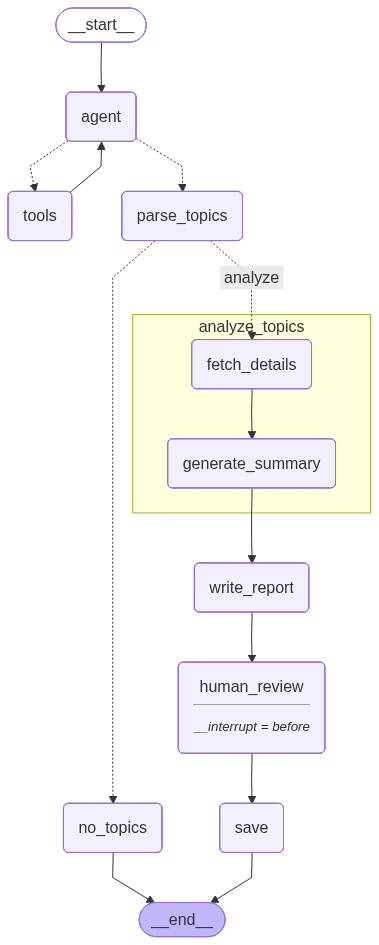

In [8]:
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## 7. Ejecutar — Fase 1: obtener y analizar noticias

In [9]:
import uuid

config = {"configurable": {"thread_id": str(uuid.uuid4())}}

print("Fase 1: arrancando agente...\n")
graph.invoke(
    {
        "messages":      [HumanMessage(content="Dame un resumen de las noticias tech más importantes de hoy.")],
        "topics":        [],
        "summaries":     [],
        "approved":      False,
        "report_content": ""
    },
    config=config
)
print("\n>>> Grafo pausado. Ejecuta la celda 8 para aprobar o cancelar.")


Fase 1: arrancando agente...

[nodo: agent]
[nodo: tools] → get_tech_headlines
[nodo: agent]
[nodo: parse_topics]
  [parse_topics] 3 temas extraídos
[nodo: analyze_topics]
  [subgrafo: fetch_details] Avances en modelos de IA para la salud y el clima
  [subgrafo: generate_summary] Avances en modelos de IA para la salud y el clima
  [subgrafo: fetch_details] Automatización de trading con IA
  [subgrafo: generate_summary] Automatización de trading con IA
  [subgrafo: fetch_details] Google lanza Gemini 3.5 Flash
  [subgrafo: generate_summary] Google lanza Gemini 3.5 Flash
[nodo: write_report]

# Tech News Report — 15/06/2026

## 1. Avances en modelos de IA para la salud y el clima

Investigadores han logrado avances significativos en modelos de inteligencia artificial que optimizan la predicción climática, alcanzando velocidades 25 veces superiores al integrar métodos generativos con datos físicos. En el ámbito de la salud, aunque la IA promete revolucionar la atención médica, algunos hosp

## 8. Human in the Loop — aprueba o cancela

- `approved = True` → guarda el informe en `tech_report.md`
- `approved = False` → cancela sin guardar nada

In [10]:
approved = True   # <-- cambia a False para cancelar

print(f"Decisión: {'GUARDAR' if approved else 'CANCELAR'}\n")

# Actualiza el estado y reanuda desde el interrupt (invoke con None)
graph.update_state(config, {"approved": approved})
graph.invoke(None, config=config)

print("\nFlujo completado.")


Decisión: GUARDAR

[nodo: save] Informe guardado en 'tech_report.md' (1975 caracteres).

Flujo completado.


## 9. Debug — inspeccionar el estado final

In [11]:
state = graph.get_state(config)

print(f"Temas extraídos:  {len(state.values.get('topics', []))}")
print(f"Resúmenes listos: {len(state.values.get('summaries', []))}")
print(f"Aprobado:         {state.values.get('approved')}")
print()

for i, msg in enumerate(state.values["messages"]):
    tipo = type(msg).__name__
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        print(f"[{i}] {tipo} → tool_calls: {[tc['name'] for tc in msg.tool_calls]}")
    else:
        preview = str(msg.content)[:100].replace("\n", " ")
        print(f"[{i}] {tipo} → {preview}...")

Temas extraídos:  3
Resúmenes listos: 3
Aprobado:         True

[0] HumanMessage → Dame un resumen de las noticias tech más importantes de hoy....
[1] AIMessage → tool_calls: ['get_tech_headlines']
[2] ToolMessage → [Latest AI breakthroughs News | June, 2026 (STARTUP EDITION)] ## Final take: what do the latest AI b...
[3] AIMessage → {   "topics": [     {"topic": "Avances en modelos de IA para la salud y el clima", "raw": "Investiga...
